# Thi is a notebook to test the project utilities

## Testing first reconstruction function in `recon/`

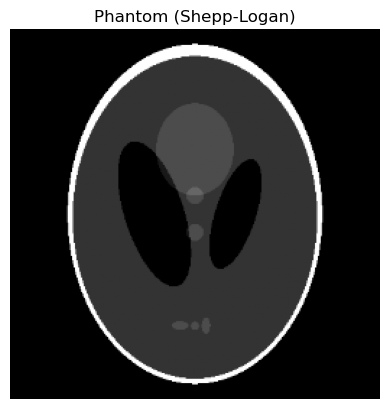

In [2]:
import sys
sys.path.append('..')

from recon.recon_utils import *
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

phantom = shepp_logan_phantom()
phantom = resize(phantom, (256, 256), mode='reflect', anti_aliasing=True)

plt.imshow(phantom, cmap='gray')
plt.title("Phantom (Shepp-Logan)")
plt.axis('off')
plt.show()

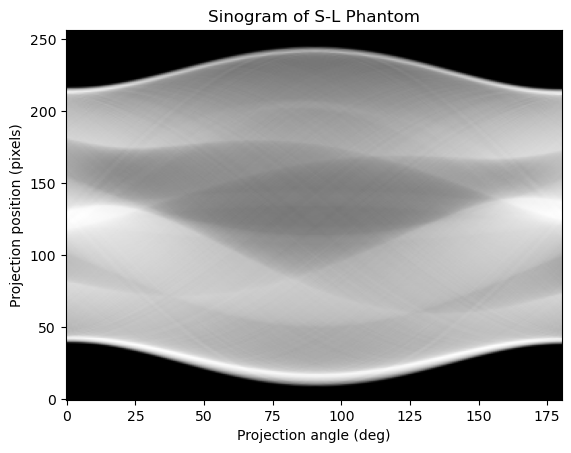

In [3]:
max_angle = 180
sinogram, angles = sinogram_from_slice(phantom, max_angle=max_angle)

dx, dy = 0.5*max_angle/max(phantom.shape), 0.5
plt.imshow(sinogram, cmap=plt.cm.Greys_r, extent=(-dx, max_angle+dx, -dy, sinogram.shape[0]+dy) ,aspect='auto')
plt.title("Sinogram of S-L Phantom")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.show()

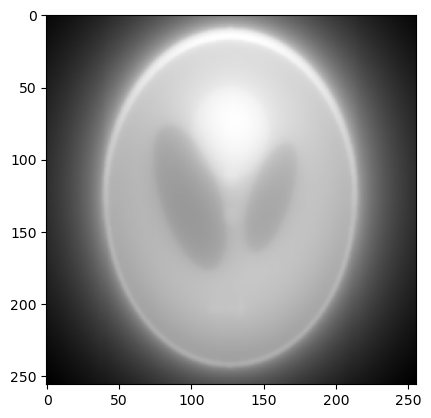

In [4]:
backproj = backprojection(sinogram, angles)
plt.imshow(backproj, cmap='gray')

Backprojecting position 68 at 47.812°


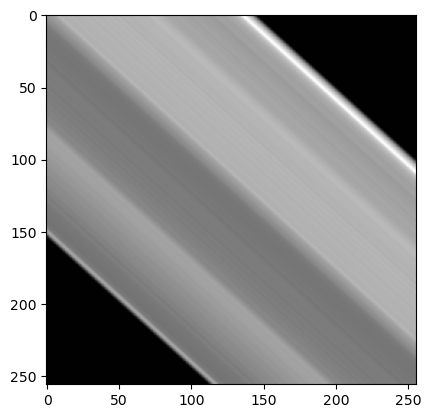

In [11]:
sbp = single_backprojection(sinogram, angles, 68, log_fn=print)
plt.imshow(sbp, cmap='grey')

## Testing master dark frame generator

Creating master dark frame from 10 uploaded images
Master dark frame saved in images/masterdark_test.tif


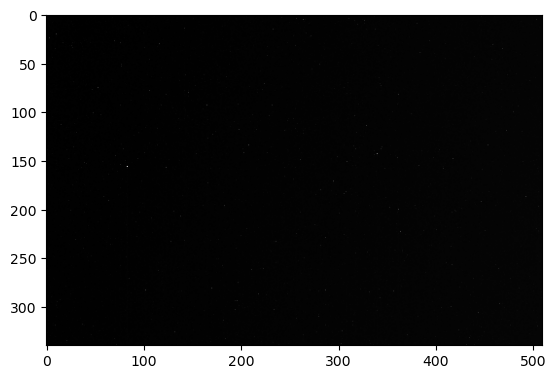

In [12]:
import sys
import matplotlib.pyplot as plt
sys.path.append('../')
from calib.calib_utils import *

DATA_DIR = Path('../data/richmond/sep20_2003_tif')
darkFrame_files = [Path(str(DATA_DIR)+"/dark4_%.3d.tif"%i) for i in range(1,11)]

master_dark = create_master_dark(darkFrame_files, output_file=Path('./images/masterdark_test.tif'))
plt.imshow(master_dark, cmap='grey')